# Basics of Neural networks and other stuff
```In this exercise you will experience working with keras, a useful tool for designing and training neural networks.```

```~Ittai Haran```

## Stage 1- predicting engineered functions
```Here you will design a simple fully connected network to predict a few simple functions. You will try different activation functions and different architectures (number of layers, size of layers).```

```The first experiment will be guided:```
- ```Read the first dataframe - function_1.csv.``` (in: https://drive.google.com/open?id=19Y9f2pkUwP7nrgbKCmCGHEomHmA0pwqx)
- ```Plot y against x. can you guess the function y(x)?```
- ```Split you data to train segment (70%) and test segment (30%).```
- ```Write a fully connected neural network with one hidden layer with 3 units. I suggest using the``` [functional API](https://keras.io/getting-started/functional-api-guide/) - ```you can also find there examples for simple working with keras.```
- ```Use tanh as an activation function for the hidden layer and a linear activation for the output layer.```
- ```Use model.summary() to look at your model's architecture.```
- ```Use mean squared error as the loss function and SGD (stochastic gradient descent) as the optimizer.```
- ```Try training the network with different batch's sizes (don't be afraid to use many epochs- you don't have a lot of data).```
- ```Plot y against x and f(x) against x on the same graph.```
- ```Compute the loss on the test segment.```
- ```Can you use a smaller hidden layer?```

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.layers import Dense, Input
from keras.models import Model
from keras.utils import plot_model
from keras.optimizers import SGD
import matplotlib.pyplot as plt
%matplotlib inline

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0361 - mean_squared_error: 0.0361
Epoch 2/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0190 - mean_squared_error: 0.0190
Epoch 3/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0126 - mean_squared_error: 0.0126
Epoch 4/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102 - mean_squared_error: 0.0102
Epoch 5/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0093 - mean_squared_error: 0.0093
Epoch 6/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0088 - mean_squared_error: 0.0088
Epoch 7/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0085 - mean_squared_error: 0.0085
Epoch 8/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0083 - mean_squared_error: 0.0083
Epoch 9/300
 85/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - mean_squared_error: 0.0081

KeyboardInterrupt: 

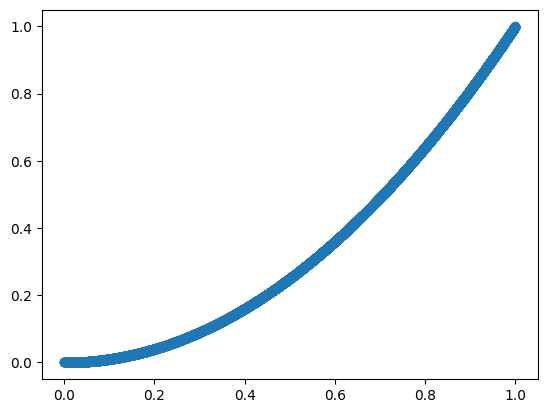

In [46]:
def get_data(csv):
    df = pd.read_csv(csv)
    plt.scatter(df['x'], df['y'])
    x_train, x_test, y_train, y_test = train_test_split(df['x'], df['y'], test_size=0.3)
    x_train = x_train.to_numpy().reshape(-1, 1)
    x_test = x_test.to_numpy().reshape(-1, 1)
    return df, x_train, x_test, y_train, y_test
df, x_train, x_test, y_train, y_test = get_data("function_1.csv")
inputs = Input(shape=(1,))
hidden = Dense(3, activation='tanh')
x = hidden(inputs)
outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs, name='model')
model.summary()
model.compile(optimizer=SGD(learning_rate=0.01), loss="mean_squared_error", metrics=["mean_squared_error"])
model.fit(x_train, y_train, batch_size=32, epochs=300)
model.evaluate(x_test, y_test)
plt.scatter(x_test, model.predict(x_test), color='green', label='predicted')
plt.legend()

```For the second experiment use the dataframe function_2.csv. Here you might need to have more layers. You might want to consider different``` [optimizers](https://keras.io/optimizers/), ```rather than SGD (for example, Adam).```

(```function_2.csv can be found in:``` https://drive.google.com/open?id=1Fk32cP-4DSZ6v175UDVz_OChHE-dFLzq)

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_37 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1557 - mean_squared_error: 0.1557
Epoch 2/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0186 - mean_squared_error: 0.0186
Epoch 3/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0081 - mean_squared_error: 0.0081
Epoch 4/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 5/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mean_squared_error: 0.0013
Epoch 6/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.5043e-04 - mean_squared_error: 9.5043e-04
Epoch 7/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.9181e-04 - mean_squared_error: 8.9181e-04
Epoch 8/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.8164e-04 - mean_squared_error: 8.8164e-04
Epoch 9/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.7472e-04 - mean_squared_error: 8.7472e-04
Epoch 10/300
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.7050e-04 - mean_squared_error: 

[1.0760962140921038e-05, 1.0760962140921038e-05]

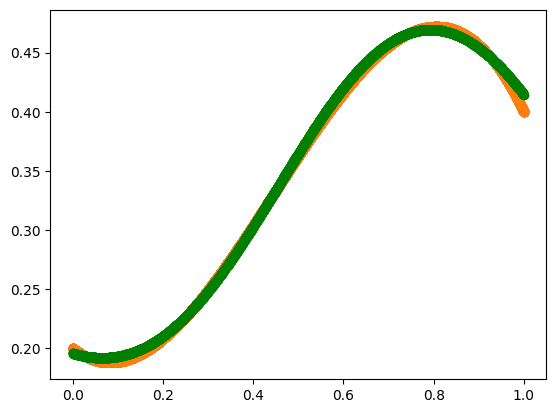

In [48]:
df_2, x_train, x_test, y_train, y_test = get_data("function_2.csv")
plt.scatter(df_2['x'], df_2['y'])
inputs = Input(shape=(1,))
hidden = Dense(3, activation='tanh')
x = hidden(inputs)
outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs, name='model')
model.summary()
model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["mean_squared_error"])
model.fit(x_train, y_train, batch_size=32, epochs=300)
plt.scatter(x_test, model.predict(x_test), color='green', label='predicted')
model.evaluate(x_test, y_test)


```For the third experiment use the dataframe function_3.csv. Try different activation functions. How many layers you had to take?```

(```function_3.csv can be found in:``` https://drive.google.com/open?id=1-XTfy6Wf0_WhEKJ9AnUGENBZRSNXkwNe)

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_49 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,561 (6.10 KB)

 Trainable params: 1,561 (6.10 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4741 - mean_squared_error: 0.4741
Epoch 2/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4183 - mean_squared_error: 0.4183
Epoch 3/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3578 - mean_squared_error: 0.3578
Epoch 4/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3237 - mean_squared_error: 0.3237
Epoch 5/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2651 - mean_squared_error: 0.2651
Epoch 6/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2280 - mean_squared_error: 0.2280
Epoch 7/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1940 - mean_squared_error: 0.1940
Epoch 8/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1677 - mean_squared_error: 0.1677
Epoch 9/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1575 - mean_squared_error: 0.1575
Epoch 10/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1533 - mean_squared_error: 0.1533
Epoch 11/

[0.0003504127962514758, 0.0003504127962514758]

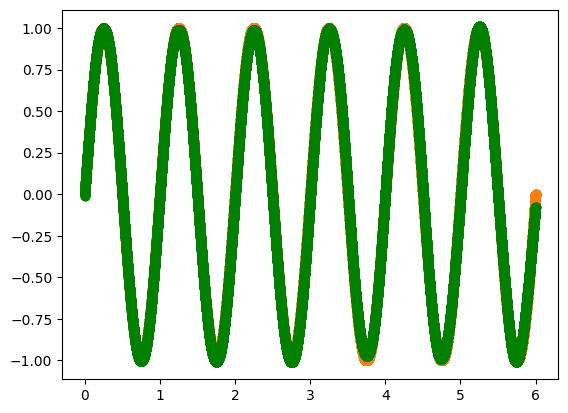

In [61]:
df_3, x_train, x_test, y_train, y_test = get_data("function_3.csv")
plt.scatter(df_3['x'], df_3['y'])
inputs = Input(shape=(1,))
x = Dense(50, activation='tanh')(inputs)
x = Dense(20, activation="tanh")(x)
x = Dense(20, activation="tanh")(x)

outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs, name='model')
model.summary()
model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["mean_squared_error"])
model.fit(x_train, y_train, batch_size=64, epochs=150)
plt.scatter(x_test, model.predict(x_test), color='green', label='predicted')
model.evaluate(x_test, y_test)


```As you maybe could've guessed, the function you fitted is``` $y = sin(x)$. ```Hence one might think it would be easy to fit a network with only one neuron, with activation of the sinus function. Try it: define a neural network with a single input and a single output, with no hidden layers, and use a sinus activation, to approximate function_3. Next we will understand why using sinus as an activation function is not a good idea.```

```You can use sin_activation provided below as the sinus activation: instead of writing activation='tanh' or activation='sigmoid', use activation=sin_activation.```

In [65]:
import tensorflow.keras.backend as K
def sin_activation(vec):
    return K.sin(vec)

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_56 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9337 - mean_squared_error: 0.9337
Epoch 2/6
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 906us/step - loss: 0.9250 - mean_squared_error: 0.9250
Epoch 3/6
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9229 - mean_squared_error: 0.9229
Epoch 4/6
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9195 - mean_squared_error: 0.9195
Epoch 5/6
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - loss: 0.9127 - mean_squared_error: 0.9127
Epoch 6/6
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 0.8978 - mean_squared_error: 0.8978
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 0.9059 - mean_squared_error: 0.9059


[0.905887246131897, 0.905887246131897]

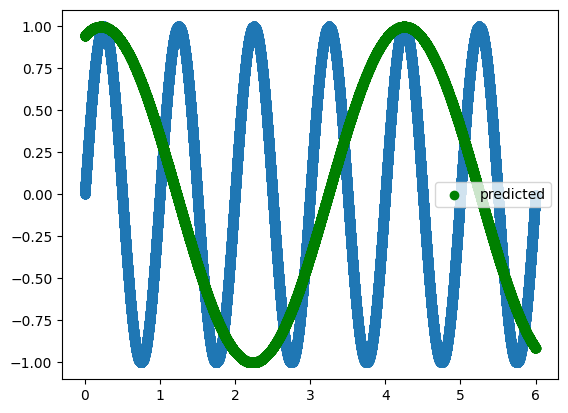

In [70]:
inputs = Input(shape=(1,))
outputs = Dense(1, activation=sin_activation)(inputs)
model = Model(inputs=inputs, outputs=outputs, name='model')
model.summary()
model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["mean_squared_error"])
model.fit(x_train, y_train, batch_size=64, epochs=6)
plt.figure()
plt.scatter(df_3['x'], df_3['y'])
plt.scatter(x_test, model.predict(x_test), color='green', label='predicted')
plt.legend()
model.evaluate(x_test, y_test)

```Let's explore the sinus activation. For this we will simplify the settings. We will generate 3 samples, with ```
$x = [0, 0.5, 1]$ ``` and ``` $y=[sin(0), sin(0.5), sin(1)]$. ```We will keep using the simplest neural network, that has one input and one output, with no hidden layers. Hence the possible functions that the network can give us are functions of the form```
<center>$y=sin(a\cdot x+b)$.<center>

```We can use the simple setting to compute and visualize the loss surface. As you recall, the loss is given by```
<center>$\sum_i{(sin(a\cdot x_i+b)-y_i)^2}$<center>

```Create a matrix so that in the (i,j) entry there will be the loss for ``` $a = \frac{2\pi}{600}\cdot i$ and $b= \frac{2\pi}{600}\cdot j$. ```Visualize this matrix using plt.imshow.```

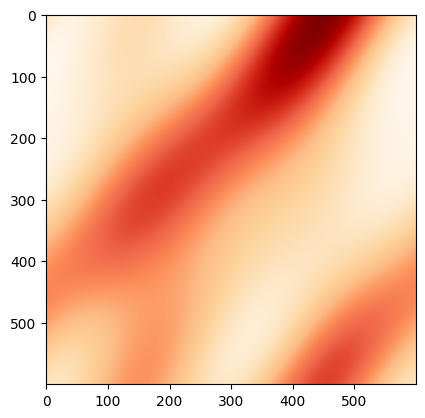

In [82]:
x = np.array([0, 0.5, 1]).reshape(-1,1)
y = np.sin(x)
inputs = Input(shape=(1,))
outputs = Dense(1, activation=sin_activation)(inputs)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["mean_squared_error"])
p = np.pi/300

loss_matrix = [
    [
        np.sum((np.sin(p*i*x + p*j) - y)**2) for j in range(600)
    ] for i in range(600)
]
plt.imshow(loss_matrix, cmap="OrRd")

```Do the same for the beloved activation, tanh. Based on the images, what makes sinus a poor activation function and tanh a good activation function? answer in ``` $\underline{a\ cell\ below}$.

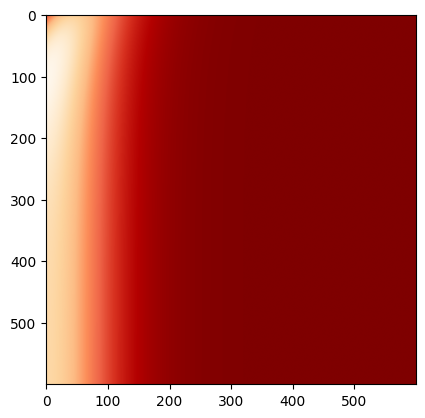

In [84]:
loss_matrix = [
    [
        np.sum((np.tanh(p*i*x + p*j) - y)**2) for j in range(600)
    ] for i in range(600)
]
plt.imshow(loss_matrix, cmap="OrRd")

Answer: sin can fall into a lot of local minima and stay in them

### Bonus:
```When training neural networks using keras we can use callback functions: There are functions that are called automatically during the training and can be of several usages. For example, we can use a callback function to save our model to a file upon the ending of an epoch.
Below you will find a custom callback that keeps the weights for a and b in your sinus model. Use it like this:```

``` python
wh = WeightsHistory()
model.fit(X_train, Y_train, batch_size = 100, epochs = 10, verbose=2, callbacks=[wh])
```

```After you try training your model using the sinus activation you can plot the path your model took on the a-b plane. Add to your loss surface visualization a plot showing the a-b values during training.```

```Note: after using plt.imshow you got an image of the size``` $600\times 600$. ```You will have to scale your a-b path accordingly to see it on the same graph. Try zooming (by changing the scale of the image, enlarging the size of your image or using any other mean) to get a better view of the a-b path. Can you explain why didn't you get a convergence?```

In [0]:
from keras.callbacks import Callback
class WeightsHistory(Callback):
    def on_train_begin(self, logs={}):
        self.a_s = []
        self.b_s = []

    def on_batch_end(self, batch, logs={}):
        weights = self.model.get_weights()
        self.a_s.append(weights[0][0][0])
        self.b_s.append(weights[1][0])

## Stage 2- predict digits from MNIST
```Use your knowledge to create a good prediction for the MNIST dataset. Note that this a classification problem, and you will have to use a different loss: for example, the binary cross entropy (log loss). Furthermore, you might want to use softmax to generate predictions. You can use activation='softmax' in the last layer of your network.
good luck!```

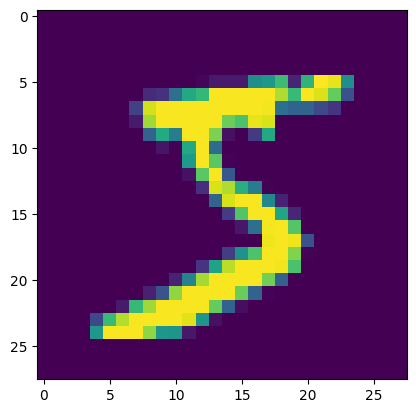

In [105]:
from keras.datasets import mnist
(X_train_images, Y_train_num), (X_test_images, Y_test_num) = mnist.load_data()
plt.imshow(X_train_images[0])
plt.show()

X_train = X_train_images.reshape(-1,784)
X_test = X_test_images.reshape(-1,784)
Y_train = pd.get_dummies(Y_train_num)
Y_test = pd.get_dummies(Y_test_num)
X_train = X_train/255
X_test = X_test/255

In [106]:
inputs = Input(shape=(784,))
x = Dense(120, activation="relu")(inputs)
x = Dense(70, activation="relu")(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(X_train, Y_train, batch_size=64, epochs=50)
model.evaluate(X_test, Y_test)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9200 - loss: 0.2740
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9664 - loss: 0.1140
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9759 - loss: 0.0793
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9814 - loss: 0.0605
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9845 - loss: 0.0479
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9874 - loss: 0.0392
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9901 - loss: 0.0313
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9919 - loss: 0.0252
Epoch 9/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9933 - loss: 0.0211
Epoch 10/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9936 - loss: 0.0196
Epoch 11/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9943 - loss: 0.0173
Epoch 12/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

[0.1489471048116684, 0.9804999828338623]

## Stage 3 - exploring deep neural networks
```In this part we will explore the problems with training deep networks.```

```We will work with the simplest data possible and will try to approximate the identity function, with one feature.
Generate 10,000 samples using np.random.random and have ``` $y=x$. ```Create a neural network with a single hidden layer with 3 neurons in it and sigmoid activation. Approximate the identity function.```

Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3880 - mean_squared_error: 0.3880
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1847 - mean_squared_error: 0.1847  
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1235 - mean_squared_error: 0.1235  
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1053 - mean_squared_error: 0.1053  
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0971 - mean_squared_error: 0.0971
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0906 - mean_squared_error: 0.0906
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0846 - mean_squared_error: 0.0846  
Epoch 8/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0788 - mean_squared_error: 0.0788  
Epoch 9/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0733 - mean_squared_error: 0.0733  
Epoch 10/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0681 - mean_squared_error: 0.0681  
Epoch 11/60
110/110 ━━━━━

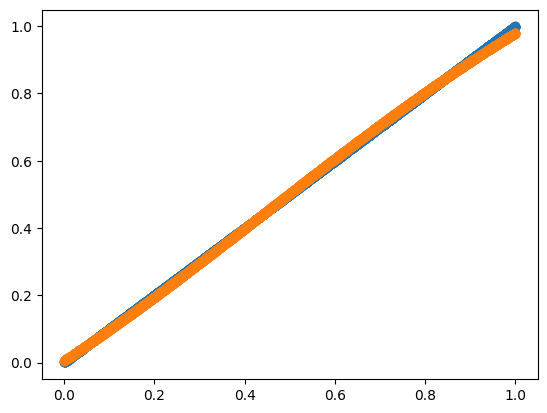

In [126]:
rand_gen = np.random.default_rng(1)
x = rand_gen.random(10000)
y = x
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
inputs = Input(shape=(1,))
x = Dense(3, activation="sigmoid")(inputs)
outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["mean_squared_error"])
model.fit(x_train, y_train, batch_size=64, epochs=60)
plt.scatter(x_test, y_test)
plt.scatter(x_test, model.predict(x_test))

```Add 50 hidden layers to your network, again, with 3 neurons in each layer and sigmoid activatoin. Try approximating the identity function using this network.```

Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1226 - mean_squared_error: 0.1226
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 8/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 9/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 10/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0838 - mean_squared_error: 0.0838
Epoch 11/60
110/110 ━━━━━━━━━━━━━━━━━━━

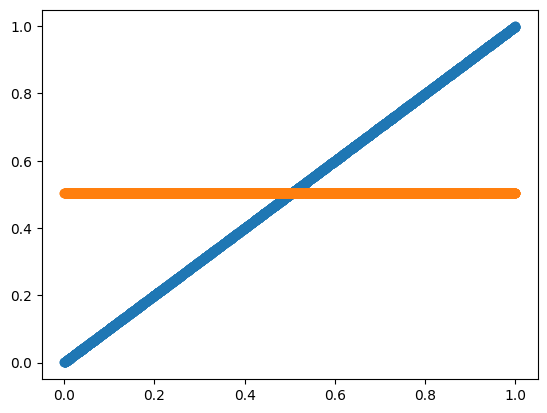

In [127]:
inputs = Input(shape=(1,))
x = inputs
for i in range(50):
    x = Dense(3, activation="sigmoid")(x)
outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=SGD(learning_rate=0.01), loss="mean_squared_error", metrics=["mean_squared_error"])
model.fit(x_train, y_train, batch_size=64, epochs=60)
plt.scatter(x_test, y_test)
plt.scatter(x_test, model.predict(x_test))

```Why isn't it working? Explain it in ``` $\underline{a\ cell\ below}$. ```In your explanation regard the process of back propagation and the formula of gradients found in the first layers of the network. Regard also the possible values of the derivative of the sigmoid function.```

Answer: Sigmoid's derivative is very small (at most ~0.15) and backpropogation from early weights multiplies it by itself on different values meaning the results are 
very close to 0 and thus barely contribute to the gradient. Learning basically doesnt happen

```Run the cell below. In weight_grads you will have a list of the gradients computed in every layer. For each layer take the maximum absolute value of the gradients. Plot a graph of the maximum values against the number of layer. Also plot it in logarithmic scale. Use it to justify your answer from before in ``` $\underline{a\ cell\ below}$.

(Skipped this; version mismatch)

In [ ]:
import numpy as np
from keras import backend as K

def get_weight_grad(model, inputs, outputs):
    """ Gets gradient of model for given inputs and outputs for all weights"""
    grads = model.optimizer.get_gradients(model.total_loss, model.trainable_weights)
    symb_inputs = (model._feed_inputs + model._feed_targets + model._feed_sample_weights)
    f = K.function(symb_inputs, grads)
    x, y, sample_weight = model._standardize_user_data(inputs, outputs)
    output_grad = f(x + y + sample_weight)
    return output_grad

weight_grads = get_weight_grad(model, X_train, Y_train)

ValueError: as_list() is not defined on an unknown TensorShape.